# CS5481 - Tutorial 5
## Large Language Models for Data Engineering

Welcome to CS5481 tutorial. In this tutorial you will learn how to **use** a large language model (LLM) as a tool for data engineering: cleaning data, labelling data, creating new data, drawing charts and analysing text.

*   (**What**) A large language model predicts the next word of a text. After training on a very large collection of text it can also *follow an instruction* and produce text, code or JSON that does the job we describe. In this tutorial we treat the model as a **function**: we give it a prompt, and we get an answer back.
*   (**Why**) A lot of data engineering is slow rather than hard: writing one more cleaning script, labelling a few thousand sentences, redrawing a chart with different colours. An LLM turns those jobs into a sentence in English, so you can build a prototype in minutes and spend your time on the parts that need human judgement. The price is that the answers are not always correct, not always the same, and not free - so we also learn how to **control** the model (temperature, JSON output), **measure** it (tokens, cost) and **check** it (voting, accuracy).

There are two standard ways to get an LLM in Python, and we will do both:

1.  call a **hosted API** - we use DeepSeek, which speaks the same "Chat Completions" protocol as OpenAI, and
2.  **deploy your own small model** (1.5B parameters) for free on Colab, behind the *same* protocol.

Because both speak the same protocol, the same five lines of Python talk to either one.

## preparation
- Python
- Python Libraries
  - `openai` (the API client; used for DeepSeek too)
  - `pandas`, `numpy`, `matplotlib` (data and plots, as in Tutorial 4)
  - `scikit-learn` (only for the "distillation" demo in Section 5)
  - `torch`, `transformers`, `fastapi`, `uvicorn` (only for the "deploy your own model" part in Section 2)
- One of the following
  - a DeepSeek API key (https://platform.deepseek.com), or
  - a Colab runtime with a GPU (`Runtime -> Change runtime type -> T4 GPU`) to run the 1.5B model yourself.

> **How to read this tutorial.** Sections 3-7 are the data engineering parts, and they work with *whichever* model you have. If you have a model key (such as DeepSeek api key) , run Section 1 and then Section 3 onward. If you have no key but you have a GPU, run Section 2 instead of Section 1.

# 0. Two ways to get an LLM, one interface

Almost every provider (OpenAI, DeepSeek, Google, Alibaba, ...) offers the same HTTP interface, called **Chat Completions**. If you write your own server that speaks this interface, your own model becomes a drop-in replacement for DeepSeek.

| | Hosted API (for example DeepSeek) | Your own small model (Colab) |
|---|---|---|
| Cost | pay per token | free (you pay with Colab GPU time) |
| Quality | very strong (hundreds of billions of parameters) | weak, but usable (1.5B parameters) |
| Privacy | your data leaves your computer | your data stays in the runtime |
| Speed | a few seconds, no setup | download + load the model first |
| Good for | real work, good labels | learning, private data, offline demos |

### 0.1 What a request and a response look like

A **request** is a list of *messages*, plus a few settings:

```json
POST /v1/chat/completions
{
  "model": "deepseek-chat",
  "messages": [
    {"role": "system", "content": "You are a helpful data engineering assistant."},
    {"role": "user",   "content": "Here is a messy dataset ..."},
    {"role": "assistant", "content": "Sure! Here is a cleaning plan ..."},
    {"role": "user",   "content": "Now give me the pandas code."}
  ],
  "temperature": 0.2,
  "max_tokens": 512,
  "stream": false
}
```

(On a recent version of vLLM, `vllm serve Qwen/Qwen2.5-1.5B-Instruct --port 8000 &` is the same thing in one word less.)

and the **response** contains the answer plus some book-keeping:

```json
{
  "id": "chatcmpl-...", "object": "chat.completion", "created": 1750000000,
  "model": "deepseek-chat",
  "choices": [{"index": 0, "finish_reason": "stop",
               "message": {"role": "assistant", "content": "Here is a cleaning plan ..."}}],
  "usage": {"prompt_tokens": 42, "completion_tokens": 128, "total_tokens": 170}
}
```

The three roles are the whole trick:

* `system` - the standing instruction ("you are a careful data engineer; answer in JSON").
* `user` - what we want right now (the task, plus the data).
* `assistant` - what the model answered before. You can also write this part yourself to show the model an example: that is **few-shot prompting**.

# 1. Calling a hosted LLM from Python
## 1.1 Install the client and store your key

The `openai` package is the standard client for every OpenAI-compatible provider, DeepSeek included.

In [1]:
!pip install -q openai

import openai
print("the openai package is ready, version", openai.__version__)

the openai package is ready, version 2.54.0


Do **not** type your key into the notebook: the key would be saved in the file, and you may share that file. Instead:

* **Colab**: click the key icon on the left, add a secret called `DEEPSEEK_API_KEY`, and turn on "Notebook access".
* **On your own computer**: run `export DEEPSEEK_API_KEY=sk-...` in the terminal before opening Jupyter.

In [5]:
import os

DEEPSEEK_API_KEY = os.environ.get("DEEPSEEK_API_KEY")

if DEEPSEEK_API_KEY is None:
    # This branch only runs inside Colab, where secrets are available.
    try:
        from google.colab import userdata
        DEEPSEEK_API_KEY = userdata.get("DEEPSEEK_API_KEY")
    except Exception:
        DEEPSEEK_API_KEY = ""

print("did we find a key?", DEEPSEEK_API_KEY != "")

did we find a key? True


In [3]:
from openai import OpenAI

# DeepSeek speaks the OpenAI protocol, so we only change the URL and the model name.
DEEPSEEK_BASE_URL = "https://api.deepseek.com"   # the client adds /v1 for you
DEEPSEEK_MODEL = "deepseek-chat"                 # or "deepseek-reasoner" (R1, thinks step by step)

# The "or dummy" part keeps this cell from crashing when the key is missing:
# the client is created, and only the call in the next cell fails, with a clear message.
client = OpenAI(api_key=DEEPSEEK_API_KEY or "dummy", base_url=DEEPSEEK_BASE_URL)

# MODEL is the name of the model we are using. In Section 2 we will point it at our own model.
MODEL = DEEPSEEK_MODEL
print("we will call:", MODEL)

we will call: deepseek-chat


## 1.2 Our first call: classify one review

In [4]:
if DEEPSEEK_API_KEY == "":
    # No key: there is nothing to call here. Jump to Section 2 and use your own model instead.
    print("no API key found - skip the rest of Section 1 and start at Section 2")
else:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {"role": "system", "content": "You are a data annotation assistant. Answer with one word."},
            {"role": "user", "content": "Classify the sentiment of this review as positive or negative.\n"
                                        "Review: 'The plot was a mess and the acting was wooden.'\n"
                                        "Sentiment:"},
        ],
        temperature=0.0,   # 0 = as steady as possible. Good for labelling.
        max_tokens=10,     # we only need one word
    )

    print("the answer is:", response.choices[0].message.content)
    print("finish_reason:", response.choices[0].finish_reason)
    print("this call used:", response.usage.total_tokens, "tokens")

the answer is: Negative
finish_reason: stop
this call used: 47 tokens


The variable `response` is a Python object built from the JSON above. In practice you will only use four things:

* `response.choices[0].message.content` - the text of the answer.
* `response.choices[0].finish_reason` - `"stop"` (finished) or `"length"` (we asked for too few `max_tokens`, so the answer is cut off).
* `response.usage.prompt_tokens` and `response.usage.completion_tokens` - what you pay for.
* `response.choices[0].message.role` - always `"assistant"`.

One warning: the model has **no memory**. Each call sends the whole conversation again. That is why long chats get expensive, and why we keep the data we send short.

A practical tip: if a call fails with a connection error, just run the cell again. The internet is not always perfect, and nothing is broken.

## 1.3 Two small functions we will reuse

Instead of writing that long call every time, we wrap it in two functions. Everything later in the tutorial uses `ask(...)`.

In [7]:
import json
import time

TOKEN_LOG = []     # every call adds its token count here, so we can look at the cost later


def chat(messages, temperature=0.0, max_tokens=1000, json_mode=False):
    """Send a list of messages to the model and return the answer as a string."""
    if json_mode:
        # json_mode asks the model to answer with one JSON object we can parse.
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            response_format={"type": "json_object"},
        )
    else:
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
        )

    TOKEN_LOG.append(response.usage.total_tokens)
    if response.choices[0].finish_reason == "length":
        print("(warning: the answer was cut off - try a bigger max_tokens)")
    return response.choices[0].message.content


def ask(prompt, system=None, temperature=0.0, max_tokens=1000, json_mode=False):
    """Ask one question and get one answer. This is the function we use everywhere below."""
    messages = []
    if system is not None:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})
    return chat(messages, temperature=temperature, max_tokens=max_tokens, json_mode=json_mode)


def tokens_used():
    """How many tokens we have used since the notebook started."""
    total = 0
    for n in TOKEN_LOG:
        total = total + n
    return total


print(ask("Reply with exactly: hello from the model", max_tokens=20))

hello from the model


## 1.4 Prompt engineering

The lecture calls a prompt *"a piece of text we put in front of the input, so that the task becomes a language-model problem"*. A good prompt usually has four parts:

1. **Role** (the `system` message): "You are a data engineer. Answer with pandas code only."
2. **Task**: say exactly what you want, and what the answer should look like ("a JSON object with the keys `label` and `confidence`").
3. **The data**, clearly separated, for example inside `<review> ... </review>`.
4. **Examples** (optional): write a few `assistant` answers yourself. That is few-shot prompting.

The two prompt *shapes* from the slides are both easy to write:

* **cloze (fill in the blank)** - `"The plot was a mess. It was ___"`, and we read the missing word from the answer;
* **prefix (instruction)** - `"Write pandas code that ..."`, and the model continues our sentence. This is what we use below.

In [8]:
review = "Battery life is amazing but the screen cracked after two days."

zero_shot = ("Classify the sentiment of the review as positive or negative.\n"
             "<review>" + review + "</review>\n")

few_shot = ("Classify the sentiment of the review as positive or negative.\n\n"
            "<review>Delivery was fast and the packaging was perfect.</review>\npositive\n\n"
            "<review>The item arrived broken and support never replied.</review>\nnegative\n\n"
            "<review>" + review + "</review>\n")

print("zero-shot:", ask(zero_shot, system="Answer with one word.", max_tokens=10))
print("few-shot :", ask(few_shot, system="Answer with one word.", max_tokens=10))

zero-shot: Negative
few-shot : negative


Both work here, but few-shot is usually better on real data, because the examples also fix the **format** of the answer. Note that this review is genuinely mixed (good battery, broken screen), so the label is a judgement call - which is exactly why the lecture warns that the template you choose changes the answer you get.

## 1.5 JSON mode: the answer as data

For data engineering, the most useful trick is `response_format={"type": "json_object"}`. The model then answers with one JSON object, which becomes a Python dictionary, which becomes a row in a table.

In [17]:
record = ask(
    "Extract the fields id, city and category from this ticket.\n"
    "Ticket: <t>ticket T-91, filed in Shanghai, about a broken payment terminal</t>\n"
    'Return JSON with the keys "id", "city" and "category".',
    temperature=0.0,
    max_tokens=100,
    json_mode=True,
)

print("the raw answer:", record)
print("as a Python dictionary:", json.loads(record))

the raw answer: {"id": "T-91", "city": "Shanghai", "category": "broken payment terminal"}
as a Python dictionary: {'id': 'T-91', 'city': 'Shanghai', 'category': 'broken payment terminal'}


## 1.6 The settings, and what they actually do

| setting | meaning | advice |
|---|---|---|
| `temperature` | how random the sampling is. 0 always picks the most likely word | 0 for extraction, labelling and code; 0.7-1.0 for brainstorming and data augmentation |
| `top_p` | only keep the most likely words whose probability adds up to `top_p` | leave it alone unless you also change `temperature` |
| `max_tokens` | the longest answer we accept | always set it; a cut-off answer has `finish_reason="length"` |
| `stop` | stop as soon as this text appears | e.g. `["\n\n"]` if you only want one line |
| `response_format` | `{"type": "json_object"}` forces JSON | use it whenever the answer is data rather than prose |
| `stream` | send the answer word by word | for chat windows |
| `seed` | ask for repeatable answers | helps, but it does not guarantee the same answer |

Let us see the effect of `temperature` on the same prompt:

In [9]:
question = "Invent a short name for a dataset about city bicycles."

print("temperature 0.0:", ask(question, temperature=0.0, max_tokens=60))
print("temperature 1.3:", ask(question, temperature=1.3, max_tokens=60))

temperature 0.0: **CityCycle**
(warning: the answer was cut off - try a bigger max_tokens)
temperature 1.3: **CityCycle** — short, alliterative, and immediately signals both the urban setting and the bike-share subject.

A few alternatives depending on flavor:
- **UrBike** — punchy, techy
- **VeloCity** — leans European/cycling-culture
-


## 1.7 Advanced: streaming

With `stream=True` we get the answer **piece by piece** instead of all at once. Each piece is a *delta*: only the new words. If we add the pieces together we get the full answer - this is how a chat window "types" the answer.

In [11]:
stream = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "List three data quality problems, one per line."}],
    temperature=0.7,
    max_tokens=120,
    stream=True,
)

for piece in stream:
    text = piece.choices[0].delta.content
    if text is not None:
        print(text, end="")     # print as it arrives
print()

Missing values
Duplicate records
Inconsistent formatting


## 1.8 Advanced: tokens, cost and rate limits

You pay for the **prompt tokens plus the completion tokens**. Three things follow from that:

* Sending a whole dataframe on every call is the fastest way to spend money. Send a short description instead (`df.dtypes`, three rows, the number of missing values), as we do in Section 3.
* Providers cache repeated prompt prefixes, and cached input tokens cost much less than new ones. So keep the part of the prompt that never changes at the front.
* "Reasoner" models (`deepseek-reasoner`) first write a long chain of thought, which you also pay for as output. Use them when you need the extra accuracy, not for labelling thousands of rows.

Check the official pricing page (https://api-docs.deepseek.com/quick_start/pricing) and compute the cost yourself.

In [12]:
print("tokens used so far:", tokens_used())
print("cost = (prompt_tokens * price_in + completion_tokens * price_out) / 1000000")
print("      fill in the two prices from the pricing page")

tokens used so far: 223
cost = (prompt_tokens * price_in + completion_tokens * price_out) / 1000000
      fill in the two prices from the pricing page


# 2. Running a model yourself (optional)

Everything after this section only uses the function `ask(...)`, so you can skip this part if you have a DeepSeek key.

Why would you run the model yourself? Because your data may be private, or because you do not want to pay for every token. You do **not** have to write a server for that: **vLLM** starts an OpenAI-compatible server for any Hugging Face model with a single command. Because it speaks the same protocol as DeepSeek, every line of code from Section 1 keeps working - you only change the URL and the model name.

What you need

* a GPU - in Colab: `Runtime -> Change runtime type -> T4 GPU`;
* about 3 GB of GPU memory for a 1.5B model in 16-bit, plus the memory for the conversation;
* a minute or two the first time, to download the weights.

## 2.1 The two commands

Run these in a Colab cell (they also work in a terminal):

```bash
!pip install -q vllm
!python -m vllm.entrypoints.openai.api_server --model Qwen/Qwen2.5-1.5B-Instruct --port 8000 &
```

The server prints a few lines while it loads the model. When it is ready you see something like:

```
INFO:     Started server process [1234]
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)
INFO:     Application startup complete.
```

## 2.2 Use it exactly like DeepSeek

The cell below checks whether a server is listening on port 8000. If it is, we point the client at it - **only the URL and the model name change** - and the same `ask(...)` works.

(Before you start vLLM, or on a machine without a GPU, the cell prints a reminder instead. That is expected.)

(If you skipped Section 1, run cells 1.1 and 1.3 first: they define `client`, `chat` and `ask`, and none of them needs a key.)

In [ ]:
import requests
from openai import OpenAI

VLLM_URL = "http://127.0.0.1:8000/v1"
VLLM_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

try:
    print("the server is serving:", requests.get(VLLM_URL + "/models", timeout=3).json())

    # the only two lines that change compared with Section 1
    client = OpenAI(base_url=VLLM_URL, api_key="not-needed")   # any non-empty key
    MODEL = VLLM_MODEL

    print(ask("In one short sentence, what is data cleaning?", max_tokens=60))
except Exception:
    print("nothing is listening on port 8000 yet.")
    print("start vLLM with the two commands above, wait about a minute, then run this cell again.")

nothing is listening on port 8000 yet.
start vLLM with the two commands above, wait about a minute, then run this cell again.


## 2.3 The settings you are most likely to change

| setting | what it does |
|---|---|
| `--model` | which Hugging Face model to serve (`Qwen/Qwen2.5-1.5B-Instruct`, `Qwen/Qwen2.5-7B-Instruct`, ...) |
| `--port` | the port; keep the client URL in step with it |
| `--max-model-len` | the longest context to accept. Smaller = less GPU memory |
| `--gpu-memory-utilization` | the share of the GPU memory vLLM may use (default 0.9) |
| `--dtype` | `auto`, `bfloat16`, `float16` |
| `--tensor-parallel-size` | how many GPUs to spread the model over |
| `--api-key` | require a key, exactly like a hosted provider |

Two last notes. vLLM is not the only option - Hugging Face TGI, Ollama and LM Studio all speak the same interface, and a hosted OpenAI-compatible endpoint works too, so your notebook does not change either way. And on a free Colab T4 you should stay around 1.5B-3B parameters; for anything bigger, use a hosted API instead.

# 3. LLMs for data preprocessing

From here on, everything is a **prompt plus a function call**. The recipe from the lecture is: *ask for the methods, then ask for the code, then run the code.*

We start from a deliberately messy dataset: a duplicated row, missing values, a number stored as text, a `999999` outlier, inconsistent capitalisation, and a date written as text.

In [13]:
import pandas as pd
import numpy as np

messy = pd.DataFrame({
    "order id":      ["o1", "o2", "o3", "o4", "o5", "o6", "o7", "o8", "o9", "o10", "o11", "o12"],
    "Created At":    ["2024-01-05", "05/01/2024", "2024-01-07", None, "2024-02-01",
                      "2024-02-03", "2024-02-03", "2024-03-11", "2024-03-12",
                      "2024-04-02", "2024-04-02", "2024-04-09"],
    "Region":        ["North", "north", "SOUTH", "South ", "East",
                      "east", "West", "west", "North", "North", "North", "East"],
    "units sold":    [10, 12, 7, 9, 40, np.nan, 15, 22, 18, 999999, 20, np.nan],
    "unit price($)": ["9.5", "9.5", "12.0", "12", "7.25",
                      "7.25", "7.25", "5.0", "5", "5.0", "5.0", "5.0"],
})

messy

,order id,Created At,Region,units sold,unit price($)
0,o1,2024-01-05,North,10.0,9.5
1,o2,05/01/2024,north,12.0,9.5
2,o3,2024-01-07,SOUTH,7.0,12.0
3,o4,None,South,9.0,12
4,o5,2024-02-01,East,40.0,7.25
5,o6,2024-02-03,east,NaN,7.25
6,o7,2024-02-03,West,15.0,7.25
7,o8,2024-03-11,west,22.0,5.0
8,o9,2024-03-12,North,18.0,5
9,o10,2024-04-02,North,999999.0,5.0


## 3.1 Ask for a generic cleaning pipeline

In [14]:
answer = ask(
    "Give a generic pandas data cleaning pipeline for a CSV file that may contain missing values, "
    "duplicated rows, inconsistent column names, and numbers stored as text. "
    "Answer as a numbered list of at most 8 short lines.",
    system="You are a concise data engineering assistant.",
    max_tokens=400,
)
print(answer)

1. Read CSV: `df = pd.read_csv(path)`.
2. Normalize column names: lowercase, strip, replace spaces with underscores.
3. Drop fully empty rows/columns.
4. Remove duplicate rows: `df.drop_duplicates()`.
5. Strip whitespace from string/object columns.
6. Coerce numeric-looking text columns via `pd.to_numeric(errors='coerce')`.
7. Handle missing values: drop or impute per column.
8. Reset index and optionally save cleaned CSV.


## 3.2 Ask for the methods, then ask for the code

Two steps work much better than one: first the model thinks about *your* data, then it writes the code for the method *you* choose.

In [15]:
question = ("I have a dataframe with a numeric column called 'units sold' that has missing values.\n"
            "The other columns are: " + str(list(messy.columns)) + "\n"
            "List 3 techniques for handling those missing values, one per line, and say which "
            "pandas function implements each one.")

print(ask(question, max_tokens=300))

1. Remove rows with missing values — `df.dropna(subset=['units sold'])`
2. Fill missing values with a constant (e.g., 0) — `df['units sold'].fillna(0)`
3. Fill missing values with the column mean (or median) — `df['units sold'].fillna(df['units sold'].mean())`


Now we ask for the code for one specific method. Models like to explain themselves, so we always cut away the explanation and keep only the code inside the ``` fences. These two helpers are used for the rest of the tutorial:

In [16]:
def extract_code(text):
    """Keep only the code inside the first pair of ``` fences."""
    if "```" not in text:
        return text.strip()
    parts = text.split("```")
    code = parts[1]                 # the part between the first two fences
    if code.startswith("python"):
        code = code[6:]             # drop the word "python" if it is there
    return code.strip()


def run_code(code, df):
    """Run the code the model wrote. The code must leave the cleaned table in the variable df."""
    space = {"df": df, "pd": pd, "np": np}     # the variables the code is allowed to see
    exec(extract_code(code), space)
    return space["df"]


code = ask(
    "Fill the missing values of the column 'units sold' with the median.\n"
    "The dataframe is already in a variable called df.\n"
    "Return only python code, no explanation.",
    temperature=0.0,
    max_tokens=200,
)

print(extract_code(code))

df['units sold'] = df['units sold'].fillna(df['units sold'].median())


In [18]:
cleaned = run_code(code, messy.copy())
print("missing values left:", cleaned["units sold"].isna().sum())
cleaned.head(3)

missing values left: 0


,order id,Created At,Region,units sold,unit price($)
0,o1,2024-01-05,North,10.0,9.5
1,o2,05/01/2024,north,12.0,9.5
2,o3,2024-01-07,SOUTH,7.0,12.0


Two warnings about running code that a model wrote:

* it runs with the same permissions as your notebook, so read it first;
* it often fails on the first try. Sending the error message back ("this failed with ... - fix it") is normal practice, not cheating.

## 3.3 Let the model write the whole pipeline

Instead of one step at a time, we can describe the table to the model and ask for one function. The description is built from the data itself, so we can reuse it on any new file.

In [19]:
def describe(df, n=3):
    """A short, cheap description of a dataframe, to put inside a prompt."""
    text = "shape: " + str(df.shape) + "\n"
    text = text + "columns and types:\n" + df.dtypes.to_string() + "\n"
    text = text + "missing values:\n" + df.isna().sum().to_string() + "\n"
    text = text + "first rows:\n" + df.head(n).to_string()
    return text


print(describe(messy))

shape: (12, 5)
columns and types:
order id          object
Created At        object
Region            object
units sold       float64
unit price($)     object
missing values:
order id         0
Created At       1
Region           0
units sold       2
unit price($)    0
first rows:
  order id  Created At Region  units sold unit price($)
0       o1  2024-01-05  North        10.0           9.5
1       o2  05/01/2024  north        12.0           9.5
2       o3  2024-01-07  SOUTH         7.0          12.0


In [20]:
instructions = ("Write a pandas function clean(df) for the dataframe described below. It should\n"
                "- strip the column names and replace spaces with underscores\n"
                "- drop duplicated rows\n"
                "- parse the column 'Created At' to datetime\n"
                "- convert the column 'unit price($)' to numbers (it is text at the moment)\n"
                "- strip whitespace and fix the capitalisation of the column 'Region'\n"
                "- fill missing numbers with the median and missing dates with the previous value\n"
                "- cap outliers of numeric columns at the 1st and 99th percentile\n"
                "Return only python code: the imports and the function clean(df). No explanation.\n\n"
                "Dataframe:\n" + describe(messy))

code = ask(instructions, system="You are a senior data engineer. Output runnable pandas code only.",
           temperature=0.0, max_tokens=900)
print(extract_code(code))

import pandas as pd
import numpy as np

def clean(df):
    df = df.copy()
    df.columns = [c.strip().replace(' ', '_') for c in df.columns]
    df = df.drop_duplicates()
    df['Created_At'] = pd.to_datetime(df['Created_At'], errors='coerce', dayfirst=True)
    df['unit_price($)'] = pd.to_numeric(
        df['unit_price($)'].astype(str).str.replace(r'[^0-9.\-]', '', regex=True),
        errors='coerce'
    )
    df['Region'] = df['Region'].astype(str).str.strip().str.capitalize()
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].fillna(df[col].median())
    df['Created_At'] = df['Created_At'].ffill()
    for col in df.select_dtypes(include=[np.number]).columns:
        lo, hi = df[col].quantile(0.01), df[col].quantile(0.99)
        df[col] = df[col].clip(lo, hi)
    return df


In [21]:
try:
    namespace = {"pd": pd, "np": np}          # the variables the generated code may use
    exec(extract_code(code), namespace)

    if "clean" in namespace:
        cleaned = namespace["clean"](messy.copy())   # we asked for a function, so we call it
    else:
        cleaned = namespace["df"]                    # the code changed df itself
    print(cleaned.dtypes)
except Exception as error:
    print("the generated code failed:", error)
    print("send the error back to the model and ask for a corrected version")
    cleaned = messy.copy()          # so that the next cell still has something to show

order_id                 object
Created_At       datetime64[ns]
Region                   object
units_sold              float64
unit_price($)           float64
dtype: object


In [ ]:
cleaned

,order_id,Created_At,Region,units_sold,unit_price($)
0,o1,2024-05-01,North,10.00,9.50
1,o2,2024-01-05,North,12.00,9.50
2,o3,2024-07-01,South,7.22,12.00
3,o4,2024-07-01,South,9.00,12.00
4,o5,2024-01-02,East,40.00,7.25
5,o6,2024-03-02,East,16.50,7.25
6,o7,2024-03-02,West,15.00,7.25
7,o8,2024-11-03,West,22.00,5.00
8,o9,2024-12-03,North,18.00,5.00
9,o10,2024-02-04,North,890003.51,5.00


Always read the result and judge it. When we ran this cell, the generated pipeline

* renamed every column and turned `unit price($)` into a number - correct;
* merged `North`, `north` and `North ` into one category - correct;
* parsed the dates with `dayfirst=True`, so `"2024-01-05"` (5 January) came out as 1 May - **wrong, and completely silent**;
* left the `999999` outlier in the table. It capped the values at the 99th percentile, and a single huge value is enough to push that percentile up. Use the median plus a few times the median absolute deviation, or simply delete impossible values.

So the function *looks* right and is not right. Run it, look at a few rows, and fix what is broken - either in a second call to the model, or by editing the code yourself.

## 3.4 Turn the answer into a record: the `ask_json` helper

Our last helper asks for JSON and tries to parse it. If the model answers with prose, we tell it off and ask again. It returns an empty dictionary if it never succeeds, so the notebook keeps running.

In [ ]:
def ask_json(prompt, system=None, temperature=0.0):
    """Ask the model for one JSON object and return it as a Python dictionary."""
    for attempt in range(3):
        text = ask(prompt, system=system, temperature=temperature, json_mode=True)
        try:
            return json.loads(extract_code(text))
        except Exception:
            prompt = prompt + "\n\nYour last answer was not valid JSON. Return JSON only."
    print("(the model did not return valid JSON)")
    return {}


raw = ask_json(
    "Map each messy column name below to a standard snake_case name.\n"
    "Columns: " + str(list(messy.columns)) + "\n"
    'Return JSON of the form {"mapping": {"<messy name>": "<standard name>"}}',
)
print(raw)

{'mapping': {'order id': 'order_id', 'Created At': 'created_at', 'Region': 'region', 'units sold': 'units_sold', 'unit price($)': 'unit_price'}}


In [ ]:
mapping = raw.get("mapping")
if mapping is None:
    mapping = {}

print("renamed columns:", list(messy.rename(columns=mapping).columns))

renamed columns: ['order_id', 'created_at', 'region', 'units_sold', 'unit_price']


# 4. LLMs for data annotation

Labelling is where LLMs save the most human time. The lecture lists sentiment analysis, topic classification, intent detection and information extraction. The recipe is always the same:

1. describe the labels and the exact output format,
2. ask for JSON,
3. **compare the model with a few examples you labelled yourself.**

In [ ]:
# Eight reviews that I labelled by hand. You will measure the model on them.
labelled = [
    ["The packaging was perfect and it arrived a day early.", "positive"],
    ["It stopped charging after one week.", "negative"],
    ["Exactly as described, would buy again.", "positive"],
    ["Delivery was late and the box was crushed.", "negative"],
    ["The battery life is amazing, easily two days.", "positive"],
    ["Support never answered my emails.", "negative"],
    ["Cheap plastic, feels like it will break soon.", "negative"],
    ["The screen is bright and the colours are great.", "positive"],
]

reviews = pd.DataFrame(labelled, columns=["review", "gold"])
reviews

,review,gold
0,The packaging was perfect and it arrived a day...,positive
1,It stopped charging after one week.,negative
2,"Exactly as described, would buy again.",positive
3,Delivery was late and the box was crushed.,negative
4,"The battery life is amazing, easily two days.",positive
5,Support never answered my emails.,negative
6,"Cheap plastic, feels like it will break soon.",negative
7,The screen is bright and the colours are great.,positive


## 4.1 Annotate one row, with a schema

In [ ]:
def annotate(text):
    """Return a record with the label, a confidence and a short reason."""
    prompt = ("Label the sentiment of the review below.\n"
              "<review>" + text + "</review>\n"
              "Allowed labels: positive, negative.\n"
              'Return JSON: {"label": "positive" or "negative", '
              '"confidence": a number from 0 to 1, "reason": "at most 12 words"}')
    return ask_json(prompt, system="You are a careful data annotator.")


print(annotate("The plot was a mess and the acting was wooden."))

{'label': 'negative', 'confidence': 0.98, 'reason': 'Plot messy, acting wooden; clearly unfavorable criticism.'}


## 4.2 Annotate the whole table, and check the result

In [ ]:
labels = []
confidences = []
reasons = []

for text in reviews["review"]:
    record = annotate(text)
    labels.append(record.get("label"))
    confidences.append(record.get("confidence"))
    reasons.append(record.get("reason"))

reviews["pred"] = labels
reviews["confidence"] = confidences
reviews["reason"] = reasons

# a comparison of two columns gives True/False, and .mean() turns that into a fraction
print("accuracy on our 8 hand labels:", round((reviews["pred"] == reviews["gold"]).mean(), 2))
reviews

accuracy on our 8 hand labels: 1.0


,review,gold,pred,confidence,reason
0,The packaging was perfect and it arrived a day...,positive,positive,1.00,Perfect packaging and early arrival indicate p...
1,It stopped charging after one week.,negative,negative,1.00,"Product failed after one week, stopped charging."
2,"Exactly as described, would buy again.",positive,positive,1.00,"Satisfied, would buy again."
3,Delivery was late and the box was crushed.,negative,negative,1.00,Late delivery and crushed box indicate poor se...
4,"The battery life is amazing, easily two days.",positive,positive,1.00,Praise for amazing battery life lasting two days.
5,Support never answered my emails.,negative,negative,0.98,"Support ignored emails, indicating poor service."
6,"Cheap plastic, feels like it will break soon.",negative,negative,0.98,Cheap plastic and likely to break soon
7,The screen is bright and the colours are great.,positive,positive,0.98,Bright screen and great colours indicate posit...


Two things to notice:

* the rows with low `confidence`, or where the model disagrees with you, are the rows **you** should look at. Sorting by confidence is a very cheap way to find bad data;
* a small local model will sometimes return nothing usable. Those rows are not an exception - they are a signal that the model is too small for the job, or that the schema is too ambitious.

In [ ]:
print("rows where the model disagreed with me:")
print(reviews[reviews["pred"] != reviews["gold"]][["review", "gold", "pred", "confidence"]])

rows where the model disagreed with me:
Empty DataFrame
Columns: [review, gold, pred, confidence]
Index: []


## 4.3 Ask several times and vote (self-consistency)

A model is a sampling machine: the same row can get different labels on different runs. A standard trick is to ask *k* times and take the majority answer. It costs more tokens, but it is more reliable, and the votes tell you which rows are difficult.

In [ ]:
def annotate_vote(text, k=3):
    """Ask k times and return the most frequent label, plus the vote count of each label."""
    votes = []
    for i in range(k):
        record = annotate(text)
        votes.append(record.get("label"))

    counts = {}
    for vote in votes:
        if vote in counts:
            counts[vote] = counts[vote] + 1
        else:
            counts[vote] = 1

    best = None
    for label in counts:
        if best is None or counts[label] > counts[best]:
            best = label
    return best, counts


tricky = "Battery life is amazing but the screen cracked after two days."
print(annotate_vote(tricky, k=3))

('negative', {'negative': 3})


## 4.4 Few-shot labelling

Instead of writing rules, show the model examples in the message list. The `assistant` messages are ours. This is the cheapest way to teach a label set the model has never seen, for example your own topic names.

In [ ]:
our_labels = ["billing", "delivery", "product quality"]

messages = [
    {"role": "system", "content": "Classify support tickets into one of " + str(our_labels) +
                                  ". Answer with the label only."},
    {"role": "user", "content": "I was charged twice for the same order."},
    {"role": "assistant", "content": "billing"},
    {"role": "user", "content": "The parcel has been 'in transit' for two weeks."},
    {"role": "assistant", "content": "delivery"},
    {"role": "user", "content": "The hinge broke the first time I opened it."},
    {"role": "assistant", "content": "product quality"},
    {"role": "user", "content": "My invoice shows an amount I never agreed to."},
]

print(chat(messages, max_tokens=15))

billing


# 5. LLMs for data augmentation

The lecture makes a data-centric point: good data is scarce, private data cannot be shared, and labelling by hand is expensive. So let the model **create** data. We look at the three ideas from the slides: synthetic data, self-instruct, and distillation.

## 5.1 Synthetic data

In [ ]:
prompt = ("Generate 6 short customer reviews about electronics: 3 negative and 3 positive. "
          "Vary the products and the reasons. "
          'Return JSON: {"reviews": [{"review": "...", "label": "positive" or "negative"}]}')

data = ask_json(prompt, temperature=0.9)
rows = data.get("reviews")
if rows is None:
    rows = []

synthetic = pd.DataFrame(rows, columns=["review", "label"])
print(synthetic["label"].value_counts())
synthetic

label
negative    3
positive    3
Name: count, dtype: int64


,review,label
0,The battery on this laptop dies within an hour...,negative
1,"Picture quality on this 4K TV is stunning, and...",positive
2,My wireless earbuds stopped charging after two...,negative
3,This mechanical keyboard feels amazing to type...,positive
4,The smartwatch's heart rate sensor is wildly i...,negative
5,"Setup for this mesh router was a breeze, and n...",positive


Adding these rows is just a `concat`, and the classes become balanced:

In [ ]:
hand_rows = reviews[["review", "gold"]].rename(columns={"gold": "label"})
augmented = pd.concat([hand_rows, synthetic], ignore_index=True)

print(augmented["label"].value_counts())
print("rows in total:", len(augmented))

label
positive    7
negative    7
Name: count, dtype: int64
rows in total: 14


## 5.2 Self-instruct: let the model write the instructions

Self-instruct, from the slides, starts from a few seed tasks and lets the model invent new ones. This is how instruction datasets are built.

In [ ]:
seeds = [
    {"instruction": "Convert 25 degrees Celsius to Fahrenheit.", "output": "77"},
    {"instruction": "What date is three days after 2024-02-27?", "output": "2024-03-01"},
]

prompt = ("Here are two example tasks:\n" + json.dumps(seeds, indent=1) + "\n\n"
          "Invent 5 new tasks in exactly the same style. Do not repeat the examples. "
          'Return JSON: {"tasks": [{"instruction": "...", "output": "..."}]}')

data = ask_json(prompt, temperature=1.0)
rows = data.get("tasks")
if rows is None:
    rows = []

pd.DataFrame(rows, columns=["instruction", "output"])

,instruction,output
0,Calculate the area of a circle with radius 5.,78.54
1,What time is 2 hours and 30 minutes after 11:4...,02:15
2,How many minutes are in 3.5 hours?,210
3,What is the sum of the first 10 positive even ...,110
4,"If a train travels at 80 km/h for 2.5 hours, h...",200


# 6. LLMs for data visualization

The lecture gives a formula, and it is worth remembering exactly that way:

> **visualization code = LLM(requirement, data description)**

We say which chart we want and describe the table; the model writes matplotlib code; we run it. This is the fastest way to have a first look at data, and a good way to learn matplotlib.

In [22]:
import matplotlib.pyplot as plt

# `metrics` has one row per month; `sales` is the classic "one value per region per quarter"
# table that the lecture used for the grouped bar chart.
metrics = pd.DataFrame({
    "month":   ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "visits":  [1200, 1500, 1700, 1600, 2100, 2400],
    "signups": [60, 75, 88, 80, 104, 122],
    "revenue": [4200, 5100, 6000, 5700, 7400, 8600],
})

sales = pd.DataFrame({
    "quarter": ["Q1", "Q2", "Q3", "Q4"],
    "North":   [120, 135, 150, 172],
    "South":   [98, 104, 99, 130],
    "East":    [143, 150, 168, 181],
    "West":    [77, 88, 95, 112],
})

metrics

,month,visits,signups,revenue
0,Jan,1200,60,4200
1,Feb,1500,75,5100
2,Mar,1700,88,6000
3,Apr,1600,80,5700
4,May,2100,104,7400
5,Jun,2400,122,8600


import numpy as np
import matplotlib.pyplot as plt

regions = ['North', 'South', 'East', 'West']
x = np.arange(len(df['quarter']))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, region in enumerate(regions):
    ax.bar(x + i * width, df[region], width, label=region)

ax.set_title('Quarterly Sales by Region')
ax.set_xlabel('Quarter')
ax.set_ylabel('Sales')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df['quarter'])
ax.legend(title='Region')

plt.tight_layout()
plt.show()
----------------------------------------------------------------------


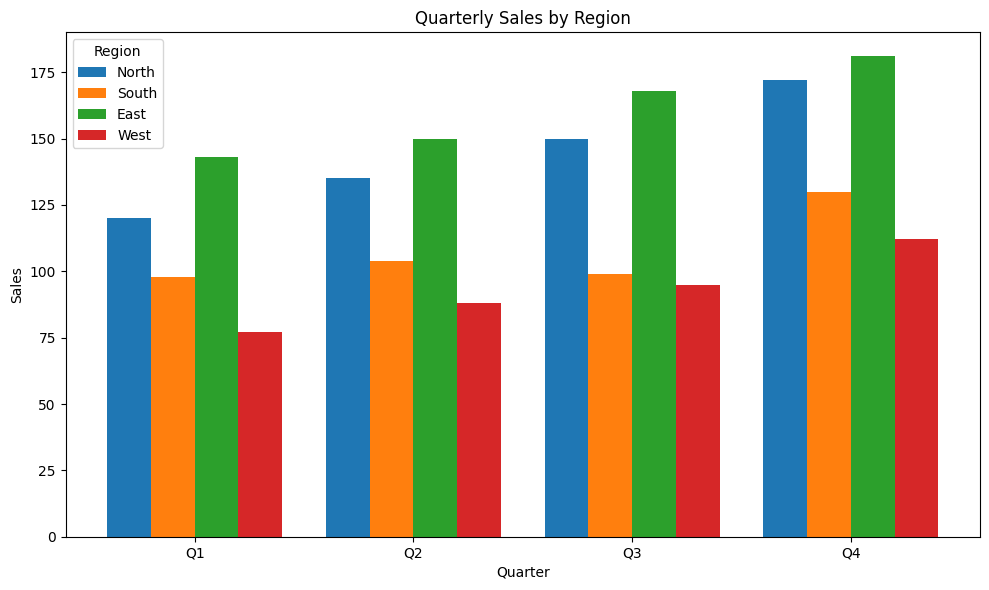

In [23]:
def llm_plot(requirement, df):
    """visualization code = LLM(requirement, data description). Then we run that code."""
    prompt = ("Write matplotlib code that draws the chart described below.\n"
              "The requirement: " + requirement + "\n\n"
              "The dataframe is already in a variable called df:\n" + describe(df, n=len(df)) + "\n\n"
              "Rules: use matplotlib only (it is already imported), use the dataframe df, add a "
              "title and axis labels, and finish with plt.show(). Return only python code.")

    code = extract_code(ask(prompt, system="You are a data visualization expert.", max_tokens=900))
    print(code)
    print("-" * 70)

    try:
        exec(code, {"df": df, "pd": pd, "np": np, "plt": plt})
    except Exception as error:
        print("the generated code failed:", error)


llm_plot("a grouped bar chart: one group of bars per quarter, one bar per region", sales)

plt.plot(df['month'], df['visits'], marker='o', label='Visits')
plt.plot(df['month'], df['signups'], marker='o', label='Signups')
plt.title('Visits and Signups Over the Months')
plt.xlabel('Month')
plt.ylabel('Count')
plt.legend()
plt.show()
----------------------------------------------------------------------


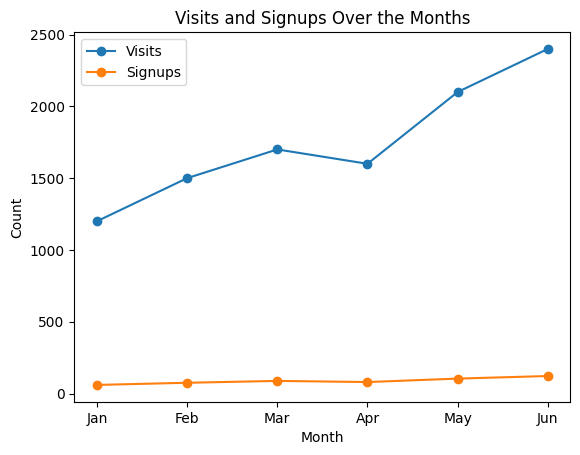

In [24]:
llm_plot("a line chart of visits and signups over the months, with markers", metrics)

Two warnings:

* the generated code runs with the same permissions as your notebook. For a small matplotlib script that is fine; for code that touches files or the network, read it first;
* a nice chart is not an analysis. The model will happily draw a misleading axis. Ask for the *insight* in a separate call, as we do in Section 7.

# 7. LLMs for text analysis

The last block of the lecture is the classic menu: **sentiment analysis, text classification, information extraction, summarization and translation**. Each one is now a prompt, and the pattern is always the same: describe the labels or the output fields, ask for JSON, and loop over the rows of a table.

In [ ]:
tickets = pd.DataFrame({
    "id": [1, 2, 3, 4, 5],
    "text": [
        "I was charged twice for the same order, please refund the second charge.",
        "The parcel has been 'in transit' for two weeks, where is it?",
        "The next public holiday is on 1 October 2024, and there are 12 new exhibits.",
        "Great news: the app finally loads in under a second after the update!",
        "Inception was directed by Christopher Nolan.",
    ],
})
tickets

,id,text
0,1,"I was charged twice for the same order, please..."
1,2,The parcel has been 'in transit' for two weeks...
2,3,"The next public holiday is on 1 October 2024, ..."
3,4,Great news: the app finally loads in under a s...
4,5,Inception was directed by Christopher Nolan.


## 7.1 Sentiment analysis

In [ ]:
print(ask("What is the sentiment of this text: 'The battery lasts two days and the screen is lovely.' "
          "Answer with one word: positive, negative or neutral.", max_tokens=10))

positive


## 7.2 Text classification

Fix the label set yourself. An open question ("what is this about?") gives you answers that you cannot count afterwards.

In [ ]:
topics = ["billing", "delivery", "product information", "other"]


def classify(text):
    prompt = ("Classify the text below into exactly one of these topics: " + str(topics) + ".\n"
              "<text>" + text + "</text>\n"
              'Return JSON: {"topic": "<one of the topics>"}')
    record = ask_json(prompt, system="You are a text classification engine.")
    return record.get("topic", "other")


predicted_topics = []
for text in tickets["text"]:
    predicted_topics.append(classify(text))

tickets["topic"] = predicted_topics
tickets

,id,text,topic
0,1,"I was charged twice for the same order, please...",billing
1,2,The parcel has been 'in transit' for two weeks...,delivery
2,3,"The next public holiday is on 1 October 2024, ...",other
3,4,Great news: the app finally loads in under a s...,other
4,5,Inception was directed by Christopher Nolan.,other


## 7.3 Information extraction

The lecture's examples - a date, a number, a name - are all "find this field and return it as a record". One schema can extract several fields at once:

In [ ]:
prompt = ("Extract information from the sentence below.\n"
          "<sentence>The next public holiday is on 1 October 2024, there are 12 new exhibits, "
          "and the film Inception was directed by Christopher Nolan.</sentence>\n"
          'Return JSON with exactly these keys: "date" (the date, or null), "number" (an integer, '
          'or null), "name" (a string, or null).')

print(ask_json(prompt))

{'date': '1 October 2024', 'number': 12, 'name': 'Inception'}


## 7.4 Summarization

In [ ]:
long_text = ("The city council approved the new transit plan on Tuesday after two years of debate. "
             "The plan replaces the ageing tram fleet, adds 40 km of dedicated bus lanes and raises "
             "parking fees in the city centre to pay for it. Supporters say it will cut commuting "
             "times by a fifth; critics say the parking fees will hurt small shops. Construction is "
             "scheduled to start in March and to finish before the next election.")

print(ask("Summarise the text in at most two sentences.\n<text>" + long_text + "</text>",
          max_tokens=120))

The city council approved a new transit plan that replaces the tram fleet, adds 40 km of bus lanes, and raises city-centre parking fees to fund it. Construction begins in March, with supporters citing shorter commutes and critics warning of harm to small shops.


## 7.5 Machine translation

In [ ]:
print(ask("Translate the sentence below into Chinese. Output only the translation.\n"
          "<text>Data quality problems are usually found after the model is deployed.</text>",
          max_tokens=80))

数据质量问题通常是在模型部署之后才被发现的。


## 7.6 All of it at once: one call, one record, one table

In practice you do not want five calls per row. Ask for **one record with all the fields you need** and loop over the table once. This is the "LLM as a data transformation" pattern, and with JSON mode it is completely mechanical.

In [ ]:
def analyze(text):
    """One call, one record."""
    prompt = ("Analyse the support ticket below and return one JSON object with the keys:\n"
              '  "sentiment": one of ["positive", "negative", "neutral"],\n'
              '  "topic": one of ["billing", "delivery", "product information", "other"],\n'
              '  "entities": a list of the important names, dates or amounts (may be empty),\n'
              '  "summary": a summary of at most 10 words.\n'
              "<ticket>" + text + "</ticket>")
    return ask_json(prompt, system="You are a text analysis engine that always answers with JSON.")


sentiments = []
summaries = []
for text in tickets["text"]:
    record = analyze(text)
    sentiments.append(record.get("sentiment"))
    summaries.append(record.get("summary"))

tickets["sentiment"] = sentiments
tickets["summary"] = summaries
tickets[["id", "topic", "sentiment", "summary"]]

,id,topic,sentiment,summary
0,1,billing,negative,"Customer charged twice, requests refund of sec..."
1,2,delivery,negative,"Parcel in transit for two weeks, customer asks..."
2,3,other,neutral,"Public holiday on 1 October 2024, 12 new exhib..."
3,4,other,positive,App loads under a second after update
4,5,other,neutral,Inception directed by Christopher Nolan.


In [ ]:
# ... and now it is an ordinary dataframe again, so we can summarise it as usual
print(tickets.groupby(["topic", "sentiment"]).size())

topic     sentiment
billing   negative     1
delivery  negative     1
other     neutral      2
          positive     1
dtype: int64


One engineering note to finish the section. At this point the *cost* of the pipeline matters: send small prompts, cache the answers (keep the result next to the text, and only re-run the rows that changed), use `temperature=0` for anything you will count, and always keep the raw model answer in its own column so you can see what happened.

# 8. Practice

1. **Temperature and correctness.** Take the mixed review from 1.4 and call the model 10 times with `temperature=0` and 10 times with `temperature=1.2`. Count the labels. Which setting would you use to label 10 000 reviews?
2. **Annotate your own data.** Choose 10 sentences from a news site or from your course notes, write your own gold label for each, and measure the model the way Section 4.2 does. List the rows where you disagree.
3. **The repair loop.** In Section 3.3, remove one line from the instructions (for example, do not tell the model the column names). How does the generated code break? Send the error message back to the model and count how many rounds it needs. This loop is the real skill of LLM-assisted coding.
4. **Self-consistency.** Run 4.3 with `k=5` on a sentence you find genuinely ambiguous. Are the votes unanimous? What does a 3-2 vote tell you about that row?
5. **Talk to the server by hand.** While Section 2.3 is running, call your own server from a terminal:

```bash
curl http://127.0.0.1:8000/v1/chat/completions -H "Content-Type: application/json" \
  -d '{"model":"local","messages":[{"role":"user","content":"Hello!"}],"max_tokens":20}'
```

### Hints

- `%%time` at the top of a cell measures how long it takes.
- To apply a function to a column and keep the result: build a list in a loop, then `df["new"] = my_list`.
- Always save the raw answer in its own column. When something looks wrong, print it.
- If JSON parsing fails, print the raw text first. It is almost always a missing brace or a sentence like "Here is your JSON:".

# 9. Summary

**The interface.** Every provider speaks Chat Completions, so one function covers all of them:

```python
client = OpenAI(base_url=..., api_key=...)      # DeepSeek, OpenAI, or our own little server
response = client.chat.completions.create(model=..., messages=[...], temperature=0.0, max_tokens=512)
print(response.choices[0].message.content)
```

**The patterns we used**

| pattern | meaning | where |
|---|---|---|
| messages and roles | system = standing instruction, user = task, assistant = example | 1.4 |
| `temperature=0` | steady answers; for extraction, labelling and code | 3, 4, 6 |
| `response_format={"type":"json_object"}` | the answer is data, not prose | 1.5, 3.4, 7 |
| `max_tokens` and `finish_reason` | notice when an answer was cut off | 1.2 |
| `stream=True` | the answer arrives piece by piece | 1.7 |
| methods first, then code | ask what to do, then ask for the code of your choice | 3.2 |
| describe the dataframe, do not paste it | cheap prompts that still scale | 3.3 |
| ask k times and vote | buy reliability with tokens | 4.3 |
| LLM labels then a small model | distillation | 5.3 |
| LLM(requirement, data description) | visualization code | 6 |
| one call, one JSON record, one table | LLM as a data transformation | 7.6 |
| our own OpenAI-compatible server | transformers plus FastAPI, about 60 lines | 2.2 |

**Four things to remember in real work**

1. An LLM is an unreliable function: not always the same answer, sometimes wrong, sometimes expensive. Wrap it, log it, measure it.
2. Write the prompt so that the answer is machine-readable (JSON, fixed label set), then work with it like any other column.
3. Check the model on rows you labelled yourself before you trust a column it produced.
4. Use the smallest model that passes your check. A 1.5B model that you run yourself can be enough for a narrow task, and it is free.

## References

- Lecture 5 slides, *Large Language Models for Data Engineering* (CS5481), and the papers they cite: Vaswani et al. 2017 (*Attention is all you need*), Radford et al. 2018 (GPT), Devlin et al. 2018 (BERT), Brown et al. 2020 (*Language models are few-shot learners*), Petroni et al. 2019 (LAMA), Li and Liang 2021 (prefix-tuning), Lester et al. 2021 (prompt tuning), Wang et al. 2022 (self-instruct).
- DeepSeek API documentation: https://api-docs.deepseek.com (models, settings, pricing, JSON mode).
- OpenAI-compatible servers to compare with Section 2.2: vLLM (`vllm serve`), Hugging Face TGI, Ollama, LM Studio.